In [1]:
from pathlib import Path
import gc
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path(
    "/ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project"
)

RAW_FILE = PROJECT / "data/raw/DR3_6D_kinematics.pkl"
PROCESSED_DIR = PROJECT / "data/processed"
FIGURE_DIR = PROJECT / "outputs/figures"

LOCAL_FILE = PROCESSED_DIR / "local_sample.parquet"
CENTRE_FILE = PROCESSED_DIR / "local_coordinate_centre.json"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

assert RAW_FILE.exists(), f"Missing file: {RAW_FILE}"

print("Python preparation ready")
print("Raw file:", RAW_FILE)
print(f"Raw size: {RAW_FILE.stat().st_size / 1e9:.3f} GB")

Python preparation ready
Raw file: /ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project/data/raw/DR3_6D_kinematics.pkl
Raw size: 10.478 GB


In [2]:
print("Loading the full Gaia catalog...")
print("This can take several minutes. Do not interrupt the kernel.")

raw = pd.read_pickle(RAW_FILE)

memory_gb = raw.memory_usage(index=True, deep=True).sum() / 1e9

print(f"Rows: {len(raw):,}")
print(f"Columns: {len(raw.columns)}")
print(f"Approximate memory: {memory_gb:.2f} GB")

Loading the full Gaia catalog...
This can take several minutes. Do not interrupt the kernel.
Rows: 29,947,047
Columns: 42
Approximate memory: 11.86 GB


In [3]:
phase_columns = [
    "x", "y", "z",
    "vx", "vy", "vz",
]

error_columns = [
    "x_err", "y_err", "z_err",
    "vx_err", "vy_err", "vz_err",
]

selection_columns = [
    "r_helio",
    "ruwe",
]

required_columns = (
    phase_columns
    + error_columns
    + selection_columns
)

missing_columns = [
    column
    for column in required_columns
    if column not in raw.columns
]

if missing_columns:
    raise KeyError(
        "Missing required columns: "
        + ", ".join(missing_columns)
    )

print("All required columns are present.")

print("\nRequired column data types:")
display(raw[required_columns].dtypes.to_frame("dtype"))

All required columns are present.

Required column data types:


,dtype
x,float64
y,float64
z,float64
vx,float64
vy,float64
vz,float64
x_err,float64
y_err,float64
z_err,float64
vx_err,float64


In [4]:
R_CUT = 0.5
RUWE_MAX = 1.4

phase_values = raw[phase_columns].to_numpy(
    dtype=np.float64,
    copy=False,
)

finite_phase_space = np.isfinite(
    phase_values
).all(axis=1)

r_helio = raw["r_helio"].to_numpy(
    dtype=np.float64,
    copy=False,
)

ruwe = raw["ruwe"].to_numpy(
    dtype=np.float64,
    copy=False,
)

quality_mask = (
    (r_helio < R_CUT)
    & (ruwe < RUWE_MAX)
    & finite_phase_space
)

keep_columns = phase_columns + error_columns

local = (
    raw.loc[quality_mask, keep_columns]
    .copy()
    .reset_index(drop=True)
)

print(f"Full catalog: {len(raw):,} stars")
print(f"Local clean sample: {len(local):,} stars")
print(
    f"Fraction retained: "
    f"{100 * len(local) / len(raw):.3f}%"
)

Full catalog: 29,947,047 stars
Local clean sample: 3,693,480 stars
Fraction retained: 12.333%


In [5]:
del raw
del phase_values
del finite_phase_space
del r_helio
del ruwe
del quality_mask

gc.collect()

local_memory_gb = (
    local.memory_usage(index=True, deep=True).sum()
    / 1e9
)

print("Full catalog released from memory.")
print(f"Local sample memory: {local_memory_gb:.3f} GB")

Full catalog released from memory.
Local sample memory: 0.355 GB


In [6]:
position_columns = ["x", "y", "z"]

coordinate_centre = (
    local[position_columns]
    .mean()
)

print("Original local coordinate centre [kpc]:")
display(coordinate_centre.to_frame("centre_kpc"))

local[position_columns] = (
    local[position_columns]
    - coordinate_centre
)

recentered_means = local[position_columns].mean()

print("Means after recentering:")
display(recentered_means.to_frame("mean_kpc"))

centre_dictionary = {
    column: float(coordinate_centre[column])
    for column in position_columns
}

with CENTRE_FILE.open("w", encoding="utf-8") as handle:
    json.dump(
        centre_dictionary,
        handle,
        indent=2,
    )

print("Saved original centre to:")
print(CENTRE_FILE)

Original local coordinate centre [kpc]:


,centre_kpc
x,-8.108382
y,0.003394
z,0.005818


Means after recentering:


,mean_kpc
x,3.723199e-16
y,4.924866e-19
z,1.231216e-19


Saved original centre to:
/ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project/data/processed/local_coordinate_centre.json


In [7]:
SEED = 20260805

TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
TEST_FRACTION = 0.15

assert np.isclose(
    TRAIN_FRACTION
    + VALIDATION_FRACTION
    + TEST_FRACTION,
    1.0,
)

rng = np.random.default_rng(SEED)

number_of_rows = len(local)
permutation = rng.permutation(number_of_rows)

number_test = int(
    round(TEST_FRACTION * number_of_rows)
)

number_validation = int(
    round(VALIDATION_FRACTION * number_of_rows)
)

test_indices = permutation[:number_test]

validation_indices = permutation[
    number_test:
    number_test + number_validation
]

train_indices = permutation[
    number_test + number_validation:
]

split_labels = np.full(
    number_of_rows,
    "train",
    dtype="U10",
)

split_labels[validation_indices] = "validation"
split_labels[test_indices] = "test"

local["split"] = pd.Categorical(
    split_labels,
    categories=[
        "train",
        "validation",
        "test",
    ],
)

split_counts = local["split"].value_counts(
    sort=False
)

print("Split counts:")
display(split_counts.to_frame("stars"))

print("Split fractions:")
display(
    (
        split_counts / len(local)
    ).to_frame("fraction")
)

Split counts:


,stars
split,
train,2585436
validation,554022
test,554022


Split fractions:


,fraction
split,
train,0.70
validation,0.15
test,0.15


In [8]:
local.to_parquet(
    LOCAL_FILE,
    index=False,
    compression="snappy",
)

print("Saved local sample:")
print(LOCAL_FILE)

print(
    f"Saved size: "
    f"{LOCAL_FILE.stat().st_size / 1e9:.3f} GB"
)

Saved local sample:
/ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project/data/processed/local_sample.parquet
Saved size: 0.369 GB


In [9]:
split_summary = (
    local.groupby(
        "split",
        observed=True,
    )[phase_columns]
    .agg(["mean", "std"])
)

display(split_summary)

x                   y                   z            \
                mean       std      mean       std      mean       std   
split                                                                    
train       0.000049  0.212012 -0.000105  0.215338 -0.000006  0.171861   
validation -0.000384  0.212058  0.000372  0.215348 -0.000111  0.171427   
test        0.000157  0.212150  0.000120  0.215653  0.000137  0.171539   

                  vx                     vy                   vz             
                mean        std        mean        std      mean        std  
split                                                                        
train       2.922479  38.774841  222.595258  28.750717  0.104045  20.615723  
validation  3.010659  38.673816  222.631192  28.633898  0.106341  20.682371  
test        2.978874  38.855566  222.616152  28.851068  0.071116  20.568417

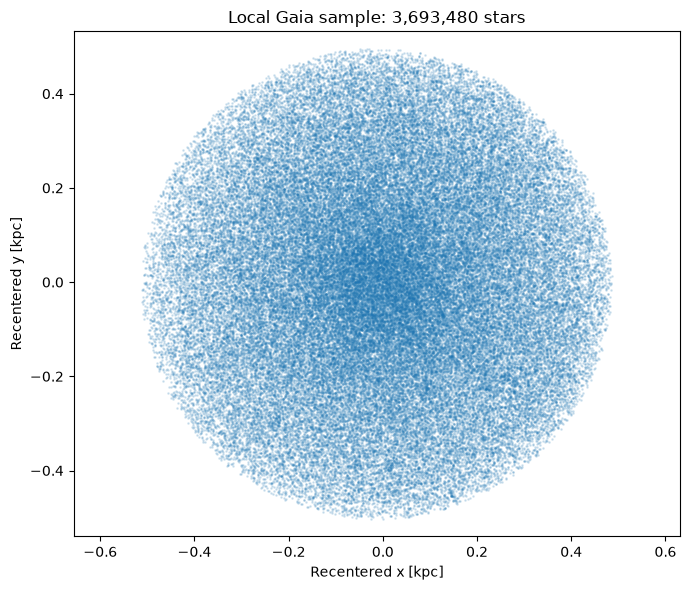

Saved: /ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project/outputs/figures/local_position_xy.png


In [10]:
PLOT_SEED = 10
MAX_PLOT_STARS = 100_000

plot_sample = local.sample(
    n=min(MAX_PLOT_STARS, len(local)),
    random_state=PLOT_SEED,
)

plt.figure(figsize=(7, 6))

plt.scatter(
    plot_sample["x"],
    plot_sample["y"],
    s=1,
    alpha=0.15,
)

plt.xlabel("Recentered x [kpc]")
plt.ylabel("Recentered y [kpc]")
plt.title(
    f"Local Gaia sample: {len(local):,} stars"
)

plt.axis("equal")
plt.tight_layout()

position_figure = (
    FIGURE_DIR
    / "local_position_xy.png"
)

plt.savefig(
    position_figure,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", position_figure)

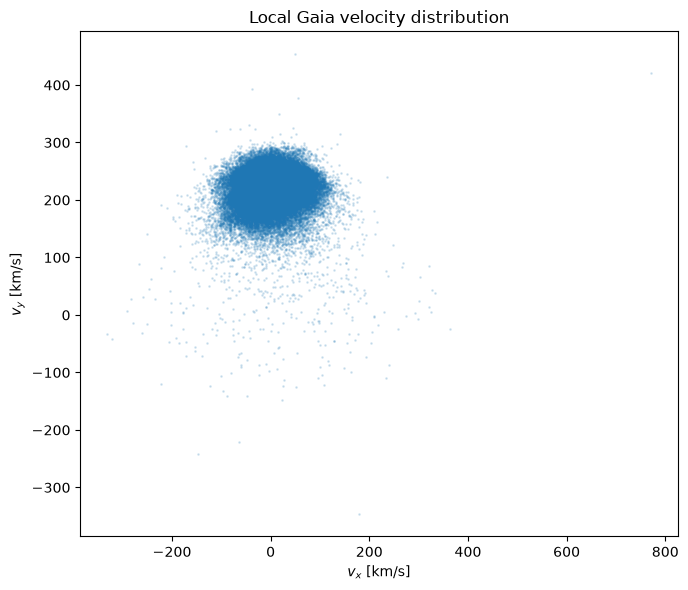

Saved: /ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project/outputs/figures/local_velocity_vx_vy.png


In [11]:
plt.figure(figsize=(7, 6))

plt.scatter(
    plot_sample["vx"],
    plot_sample["vy"],
    s=1,
    alpha=0.15,
)

plt.xlabel(r"$v_x$ [km/s]")
plt.ylabel(r"$v_y$ [km/s]")
plt.title("Local Gaia velocity distribution")

plt.tight_layout()

velocity_figure = (
    FIGURE_DIR
    / "local_velocity_vx_vy.png"
)

plt.savefig(
    velocity_figure,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", velocity_figure)

In [12]:
print("DATA PREPARATION COMPLETE")
print("=" * 60)

print(f"Local stars: {len(local):,}")

for split_name in [
    "train",
    "validation",
    "test",
]:
    count = int(
        (local["split"] == split_name).sum()
    )
    print(f"{split_name:10s}: {count:,}")

print(
    f"\nCached data: "
    f"{LOCAL_FILE}"
)

print(
    f"Cache size: "
    f"{LOCAL_FILE.stat().st_size / 1e9:.3f} GB"
)

print("\nPosition centre before recentering:")
print(coordinate_centre)

DATA PREPARATION COMPLETE
Local stars: 3,693,480
train     : 2,585,436
validation: 554,022
test      : 554,022

Cached data: /ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project/data/processed/local_sample.parquet
Cache size: 0.369 GB

Position centre before recentering:
x   -8.108382
y    0.003394
z    0.005818
dtype: float64
